# Notebook 1: Factorization Machine (FM) from Scratch
### Predicting Risky Drug Combinations Using Factorization Machines

This notebook demonstrates building and training a **Factorization Machine (FM) from scratch using NumPy only**.

---

## 1. Problem
Predict whether combining two drugs results in a **Severe** adverse interaction (`Label = 1`) or **Not severe / Mild-Moderate** (`Label = 0`).
Drug interactions are an ideal application for recommender-style factorization models: Drug 1 represents the first entity, Drug 2 represents the second entity, and their combination produces a risk interaction.

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

SEED = 42
np.random.seed(SEED)
print("Environment initialized. SEED =", SEED)

/home/natnale/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-ir70hmn8 because there was an issue with the default path (/home/natnale/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Environment initialized. SEED = 42


## 2. Dataset
The dataset consists of 40,000 interactions across 420 unique drugs. The target is binary and significantly imbalanced (only ~16.2% Severe), making F1 score the primary metric.

In [2]:
data_path = "../data/db_drug_interactions_severity.csv" if os.path.exists("../data/db_drug_interactions_severity.csv") else "db_drug_interactions_severity.csv"
df_raw = pd.read_csv(data_path)

print(f"Shape: {df_raw.shape}")
print(f"Missing values: {df_raw.isnull().sum().sum()}")
print(f"Duplicates: {df_raw.duplicated().sum()}")

counts = df_raw["Label"].value_counts()
percentages = df_raw["Label"].value_counts(normalize=True) * 100
print("\nClass Distribution:")
print(pd.DataFrame({"Count": counts, "Percentage (%)": percentages.round(2)}))
df_raw.head(3)

Shape: (40000, 5)
Missing values: 0


Duplicates: 0

Class Distribution:
       Count  Percentage (%)
Label                       
0      33511           83.78
1       6489           16.22


,Drug 1,Drug 2,Interaction Description,Severity,Label
0,Phenytoin,Zuclopenthixol,The serum concentration of Zuclopenthixol can ...,Mild,0
1,Everolimus,Atomoxetine,The serum concentration of Atomoxetine can be ...,Moderate,0
2,Diclofenac,Torasemide,Diclofenac may decrease the diuretic activitie...,Mild,0


## 3. Leakage Prevention
1. **Feature Restriction**: Inputs are strictly `Drug 1` and `Drug 2`. `Interaction Description` and `Severity` are excluded to prevent data leakage.
2. **Pair-Group Integrity**: Symmetric pairs $(A, B)$ and $(B, A)$ share the same interaction mechanism and must never be separated across train/validation/test splits. We group pairs by canonical key `tuple(sorted([Drug 1, Drug 2]))`.

In [3]:
df = df_raw[["Drug 1", "Drug 2", "Label"]].copy()
df["_pair_key"] = df.apply(lambda r: tuple(sorted([r["Drug 1"], r["Drug 2"]])), axis=1)
n_pairs = df["_pair_key"].nunique()
print(f"Total rows: {len(df)} | Unique unordered pairs: {n_pairs}")
print(f"Reversible pairs grouped together: {len(df) - n_pairs} pairs appear in both directions.")

Total rows: 40000 | Unique unordered pairs: 39959
Reversible pairs grouped together: 41 pairs appear in both directions.


## 4. Split
The dataset is partitioned into 70% Train, 15% Validation, and 15% Test sets using stratified group splitting. We also ensure every drug appearing in validation/test is present in training.

In [4]:
train_path = "../data/split_train.csv" if os.path.exists("../data/split_train.csv") else "split_train.csv"
val_path   = "../data/split_val.csv" if os.path.exists("../data/split_val.csv") else "split_val.csv"
test_path  = "../data/split_test.csv" if os.path.exists("../data/split_test.csv") else "split_test.csv"
map_path   = "../data/drug_mapping.json" if os.path.exists("../data/drug_mapping.json") else "drug_mapping.json"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

with open(map_path) as f:
    mapping = json.load(f)
drug_to_id = mapping["drug_to_id"]
n_drugs = mapping["n_drugs"]

print(f"{'Split':<8} {'Rows':>7}  {'Severe Count':>14}  {'Severe %':>10}")
print("-" * 45)
for name, s_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    s_count = int((s_df["Label"] == 1).sum())
    print(f"{name:<8} {len(s_df):>7}  {s_count:>14}  {100.0 * s_count / len(s_df):>9.2f}%")
print(f"\nUnique drugs in vocabulary: {n_drugs}")

Split       Rows    Severe Count    Severe %
---------------------------------------------
Train      28002            4544      16.23%
Val         5999             973      16.22%
Test        5999             972      16.20%

Unique drugs in vocabulary: 420


## 5. Model Mathematics
For Drug 1 index $i$ and Drug 2 index $j$, the Factorization Machine computes:
$$\hat{y} = b + w_1[i] + w_2[j] + \langle v_1[i],\, v_2[j] \rangle$$
$$p = \sigma(\hat{y}) = \frac{1}{1 + e^{-\hat{y}}}$$

**Gradients (Binary Cross-Entropy Loss):**
For batch size $B$, the residual is $r_n = \frac{p_n - y_n}{B}$:
- $\frac{\partial L}{\partial b} = \sum_{n=1}^B r_n$
- $\frac{\partial L}{\partial w_1[i]} = \sum_{n: \text{drug}_1=i} r_n, \quad \frac{\partial L}{\partial w_2[j]} = \sum_{n: \text{drug}_2=j} r_n$
- $\frac{\partial L}{\partial v_1[i]} = \sum_{n: \text{drug}_1=i} r_n \cdot v_2[j_n], \quad \frac{\partial L}{\partial v_2[j]} = \sum_{n: \text{drug}_2=j} r_n \cdot v_1[i_n]$

## 6. Implementation
Implemented in pure NumPy with numerically stable sigmoid and sparse gradient accumulation (`np.add.at`).

In [5]:
class FM:
    def __init__(self, n_drugs, k, seed=SEED):
        rng = np.random.default_rng(seed)
        scale = 1.0 / np.sqrt(k)
        self.n_drugs = n_drugs
        self.k = k
        self.b = 0.0
        self.w1 = np.zeros(n_drugs, dtype=np.float64)
        self.w2 = np.zeros(n_drugs, dtype=np.float64)
        self.v1 = rng.uniform(-scale, scale, (n_drugs, k))
        self.v2 = rng.uniform(-scale, scale, (n_drugs, k))

    def forward(self, idx1, idx2):
        linear = self.b + self.w1[idx1] + self.w2[idx2]
        dot_prod = np.sum(self.v1[idx1] * self.v2[idx2], axis=1)
        return linear + dot_prod

    def predict_proba(self, idx1, idx2):
        z = self.forward(idx1, idx2)
        return np.where(z >= 0, 1.0 / (1.0 + np.exp(-z)), np.exp(z) / (1.0 + np.exp(z)))

    def loss(self, idx1, idx2, y):
        p = np.clip(self.predict_proba(idx1, idx2), 1e-12, 1.0 - 1e-12)
        return float(-np.mean(y * np.log(p) + (1.0 - y) * np.log(1.0 - p)))

    def gradients(self, idx1, idx2, y):
        B = len(y)
        p = self.predict_proba(idx1, idx2)
        r = (p - y) / B
        grad_b = float(r.sum())
        grad_w1, grad_w2 = np.zeros_like(self.w1), np.zeros_like(self.w2)
        np.add.at(grad_w1, idx1, r)
        np.add.at(grad_w2, idx2, r)
        grad_v1, grad_v2 = np.zeros_like(self.v1), np.zeros_like(self.v2)
        np.add.at(grad_v1, idx1, r[:, None] * self.v2[idx2])
        np.add.at(grad_v2, idx2, r[:, None] * self.v1[idx1])
        return {'b': grad_b, 'w1': grad_w1, 'w2': grad_w2, 'v1': grad_v1, 'v2': grad_v2}

    def step(self, grads, lr):
        self.b  -= lr * grads['b']
        self.w1 -= lr * grads['w1']
        self.w2 -= lr * grads['w2']
        self.v1 -= lr * grads['v1']
        self.v2 -= lr * grads['v2']

    def save(self, path):
        np.savez(path, b=self.b, w1=self.w1, w2=self.w2, v1=self.v1, v2=self.v2, n_drugs=self.n_drugs, k=self.k)

    @classmethod
    def load(cls, path):
        d = np.load(path)
        m = cls(int(d['n_drugs']), int(d['k']))
        m.b, m.w1, m.w2, m.v1, m.v2 = float(d['b']), d['w1'], d['w2'], d['v1'], d['v2']
        return m

print("NumPy FM implemented successfully.")

NumPy FM implemented successfully.


## 7. Training
Mini-batch Stochastic Gradient Descent (SGD) with batch size = 256 and learning rate = 0.01.

In [6]:
def encode_data(df, mapping):
    i1 = df["Drug 1"].map(mapping).values.astype(np.int32)
    i2 = df["Drug 2"].map(mapping).values.astype(np.int32)
    y = df["Label"].values.astype(np.float32)
    return i1, i2, y

train_i1, train_i2, y_train = encode_data(train_df, drug_to_id)
val_i1,   val_i2,   y_val   = encode_data(val_df, drug_to_id)
test_i1,  test_i2,  y_test  = encode_data(test_df, drug_to_id)

def train_fm(model, epochs=50, batch_size=256, lr=0.01, verbose=False):
    rng = np.random.default_rng(SEED)
    N = len(y_train)
    history = {'train_loss': [], 'val_loss': []}
    for ep in range(1, epochs + 1):
        p = rng.permutation(N)
        shuf_i1, shuf_i2, shuf_y = train_i1[p], train_i2[p], y_train[p]
        for s in range(0, N, batch_size):
            b_i1, b_i2, b_y = shuf_i1[s:s+batch_size], shuf_i2[s:s+batch_size], shuf_y[s:s+batch_size]
            model.step(model.gradients(b_i1, b_i2, b_y), lr)
        tl = model.loss(train_i1, train_i2, y_train)
        vl = model.loss(val_i1, val_i2, y_val)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        if verbose and (ep % 10 == 0 or ep == 1):
            print(f"  Epoch {ep:>2}/{epochs} | Train Loss: {tl:.4f} | Val Loss: {vl:.4f}")
    return history

print("Training function defined.")

Training function defined.


## 8. Benchmarks
We train four FM models across embedding dimensions $k \in [4, 8, 16, 32]$ and tune the classification threshold on the validation set.

In [7]:
results = []
models = {}
histories = {}

for k in [4, 8, 16, 32]:
    print(f"Training FM with k={k}...")
    m = FM(n_drugs, k=k, seed=SEED)
    h = train_fm(m, epochs=50, batch_size=256, lr=0.01)
    models[k] = m
    histories[k] = h
    
    # Validation threshold tuning
    probs_val = m.predict_proba(val_i1, val_i2)
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.10, 0.65, 0.05):
        f = f1_score(y_val, (probs_val >= t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, round(float(t), 2)
            
    preds_val = (probs_val >= best_t).astype(int)
    results.append({
        "k": k,
        "threshold": best_t,
        "val_loss": round(m.loss(val_i1, val_i2, y_val), 4),
        "val_accuracy": round(accuracy_score(y_val, preds_val), 4),
        "val_precision": round(precision_score(y_val, preds_val, zero_division=0), 4),
        "val_recall": round(recall_score(y_val, preds_val, zero_division=0), 4),
        "val_f1": round(best_f1, 4),
        "n_params": 1 + 2 * n_drugs + 2 * n_drugs * k
    })

exp_df = pd.DataFrame(results)
display(exp_df)

Training FM with k=4...


Training FM with k=8...


Training FM with k=16...


Training FM with k=32...


,k,threshold,val_loss,val_accuracy,val_precision,val_recall,val_f1,n_params
0,4,0.15,0.4309,0.4167,0.1962,0.8386,0.3181,4201
1,8,0.15,0.4310,0.3744,0.1977,0.9342,0.3263,7561
2,16,0.15,0.4300,0.3329,0.1926,0.9753,0.3217,14281
3,32,0.15,0.4301,0.2835,0.1839,0.9938,0.3103,27721


## 9. Model Selection
Based strictly on validation F1, **$k = 8$** (Threshold = 0.15, Val F1 = **0.3263**) is selected as the optimal FM configuration.

Selected Best FM Model: k = 8 | Tuned Threshold = 0.15


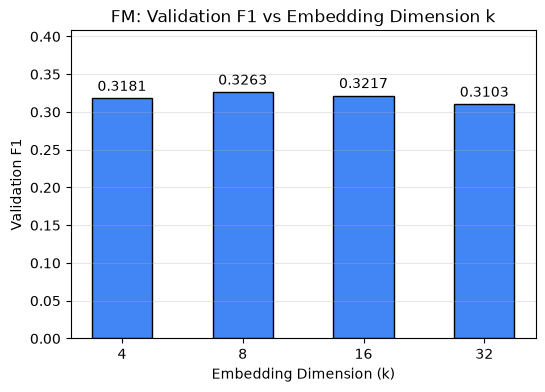

In [8]:
best_k = int(exp_df.loc[exp_df["val_f1"].idxmax(), "k"])
best_threshold = float(exp_df.loc[exp_df["k"] == best_k, "threshold"].values[0])
best_fm = models[best_k]
print(f"Selected Best FM Model: k = {best_k} | Tuned Threshold = {best_threshold}")

# Plot validation F1 vs k
plt.figure(figsize=(6, 4))
bars = plt.bar([str(k) for k in exp_df['k']], exp_df['val_f1'], color='#4285F4', edgecolor='black', width=0.5)
plt.bar_label(bars, fmt='%.4f', padding=3)
plt.xlabel('Embedding Dimension (k)')
plt.ylabel('Validation F1')
plt.title('FM: Validation F1 vs Embedding Dimension k')
plt.ylim(0, max(exp_df['val_f1']) * 1.25)
plt.grid(axis='y', alpha=0.3)
plt.show()

## 10. Final Test Results
The frozen model is evaluated **once** on the held-out test set.

In [9]:
probs_test = best_fm.predict_proba(test_i1, test_i2)
preds_test = (probs_test >= best_threshold).astype(int)

acc  = accuracy_score(y_test, preds_test)
prec = precision_score(y_test, preds_test, zero_division=0)
rec  = recall_score(y_test, preds_test, zero_division=0)
f1   = f1_score(y_test, preds_test, zero_division=0)
cm   = confusion_matrix(y_test, preds_test)
tn, fp, fn, tp = cm.ravel()

print("=" * 50)
print(f"FINAL FM TEST EVALUATION (k={best_k}, Threshold={best_threshold})")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  TP={tp}, TN={tn}, FP={fp}, FN={fn}")

FINAL FM TEST EVALUATION (k=8, Threshold=0.15)
  Accuracy  : 0.3731
  Precision : 0.1953
  Recall    : 0.9198
  F1 Score  : 0.3222
  TP=894, TN=1344, FP=3683, FN=78


## 11. Explanation of One Drug Pair
We decompose the prediction for **Dronedarone** (antiarrhythmic) and **Atenolol** (beta-blocker) into its four additive components.

In [10]:
d1, d2 = "Dronedarone", "Atenolol"
i, j = drug_to_id[d1], drug_to_id[d2]

b_val = best_fm.b
w1_val = best_fm.w1[i]
w2_val = best_fm.w2[j]
dot_val = float(np.dot(best_fm.v1[i], best_fm.v2[j]))
z = b_val + w1_val + w2_val + dot_val
prob = float(best_fm.predict_proba(np.array([i]), np.array([j]))[0])

print("=" * 50)
print(f"Prediction Breakdown: {d1} + {d2}")
print("=" * 50)
print(f"  Global bias       (b)       : {b_val:+.4f}")
print(f"  Drug 1 weight     (w1)      : {w1_val:+.4f}")
print(f"  Drug 2 weight     (w2)      : {w2_val:+.4f}")
print(f"  Embedding dot     <v1, v2>  : {dot_val:+.4f}")
print(f"  Logit             (z)       : {z:+.4f}")
print(f"  Probability       (p)       : {prob:.4f}")
print(f"  Classification (>= {best_threshold}) : {'Severe (1)' if prob >= best_threshold else 'Not Severe (0)'}")

Prediction Breakdown: Dronedarone + Atenolol
  Global bias       (b)       : -1.6232
  Drug 1 weight     (w1)      : +0.0492
  Drug 2 weight     (w2)      : +0.0121
  Embedding dot     <v1, v2>  : -0.1679
  Logit             (z)       : -1.7298
  Probability       (p)       : 0.1506
  Classification (>= 0.15) : Severe (1)


## 12. Live Demonstration
Loads the saved `fm_k8.npz` checkpoint directly from disk and predicts risk for any drug pair **without retraining**.

In [11]:
# Load checkpoint from disk (no retraining)
ckpt_file = "../models/fm/fm_k8.npz" if os.path.exists("../models/fm/fm_k8.npz") else "fm_k8.npz"
loaded_fm = FM.load(ckpt_file)
demo_threshold = 0.15

def live_predict(drug1, drug2):
    if drug1 not in drug_to_id or drug2 not in drug_to_id:
        return f"One or both drugs not in vocabulary."
    idx1, idx2 = np.array([drug_to_id[drug1]]), np.array([drug_to_id[drug2]])
    p = float(loaded_fm.predict_proba(idx1, idx2)[0])
    pred = "Severe (High Risk)" if p >= demo_threshold else "Not Severe (Low/Moderate Risk)"
    return {"Drug 1": drug1, "Drug 2": drug2, "Probability": round(p, 4), "Prediction": pred}

demo_pairs = [
    ("Dronedarone", "Atenolol"),
    ("Methadone", "Sulfisoxazole"),
    ("Abiraterone", "Acebutolol"),
    ("Paliperidone", "Chloroquine"),
]

print(f"Loaded frozen model from {ckpt_file}. Testing live predictions:")
pd.DataFrame([live_predict(d1, d2) for d1, d2 in demo_pairs])

Loaded frozen model from ../models/fm/fm_k8.npz. Testing live predictions:


,Drug 1,Drug 2,Probability,Prediction
0,Dronedarone,Atenolol,0.1506,Severe (High Risk)
1,Methadone,Sulfisoxazole,0.1732,Severe (High Risk)
2,Abiraterone,Acebutolol,0.1415,Not Severe (Low/Moderate Risk)
3,Paliperidone,Chloroquine,0.1799,Severe (High Risk)
